# 07_report_generation
## Enterprise Credit Risk Investigation & Reporting Engine

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib


In [2]:

application_train = pd.read_csv(
    "../data/processed/engineered_credit_risk_dataset.csv"
)

print(application_train.shape)


(307511, 170)


In [3]:

xgb_model = joblib.load(
    "../models/final_credit_risk_xgboost_model.pkl"
)

print("Model loaded successfully.")


Model loaded successfully.


In [4]:

feature_columns = [

    "ANNUITY_TO_INCOME",
    "CREDIT_TO_INCOME",
    "FREE_CASH_FLOW",
    "DEBT_TO_INCOME",
    "CREDIT_TO_ANNUITY_RATIO",
    "CREDIT_TO_GOODS_RATIO",
    "DOWN_PAYMENT",

    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_STD",
    "CREDIT_EXT_RATIO",

    "DEBT_PER_BUREAU_RECORD",
    "OVERDUE_PER_BUREAU_RECORD",
    "ACTIVE_DEBT_RATIO",
    "MEAN_DAYS_CREDIT",
    "LAST_ACTIVE_DAYS_CREDIT",

    "APPLICATIONS_PER_INCOME",
    "PREVIOUS_APPLICATION_COUNT",
    "RECENT_APPLICATION_COUNT",
    "BORROWING_ACCELERATION_RATIO",

    "LATE_PAYMENT_COUNT",
    "MISSED_PAYMENTS_PER_LOAN",
    "AVG_PAYMENT_DELAY",
    "AVG_PAYMENT_DEFICIT",
    "REPAYMENT_INSTABILITY",

    "LATE_PAYMENTS_LAST_90D",
    "AVG_PAYMENT_DELAY_LAST_90D",
    "RECENT_TO_HISTORICAL_DELAY_RATIO",
    "RECENT_DELAY_TREND",
    "RECENT_PAYMENT_DEFICIT",
    "PAYMENT_DEFICIT_TREND",
    "RECENT_PAYMENT_STABILITY",

    "YEARS_EMPLOYED",
    "EMPLOYMENT_TO_AGE_RATIO",
    "AGE_YEARS",

    "MAX_INSTALLMENT",
    "ANNUITY_TO_MAX_INSTALLMENT_RATIO",

    "BEHAVIORAL_RISK_SCORE"
]


In [5]:

X = application_train[feature_columns]
y = application_train["TARGET"]

application_train["PD"] = (
    xgb_model.predict_proba(X)[:,1]
)

application_train["RISK_SEGMENT"] = pd.cut(

    application_train["PD"],

    bins=[0, 0.10, 0.25, 0.50, 1.00],

    labels=[
        "LOW",
        "MEDIUM",
        "HIGH",
        "VERY_HIGH"
    ]
)

print(application_train[[
    "TARGET",
    "PD",
    "RISK_SEGMENT"
]].head())


   TARGET        PD RISK_SEGMENT
0       1  0.439965         HIGH
1       0  0.080580          LOW
2       0  0.064061          LOW
3       0  0.073943          LOW
4       0  0.166013       MEDIUM


/tmp/ipykernel_10894/3432546852.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_train["PD"] = (
/tmp/ipykernel_10894/3432546852.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_train["RISK_SEGMENT"] = pd.cut(


In [6]:

explainer = shap.TreeExplainer(
    xgb_model
)

shap_values = explainer.shap_values(X)


In [7]:

def plot_customer_shap(top_positive):

    plt.figure(figsize=(10,6))

    plt.barh(

        top_positive["Feature"][::-1],

        top_positive["SHAP"][::-1]
    )

    plt.xlabel(
        "SHAP Contribution"
    )

    plt.title(
        "Top SHAP Risk Drivers"
    )

    plt.show()


In [8]:

def load_customer_events(customer_id):

    installments = pd.read_csv(
        "../data/raw/installments_payments.csv",
        usecols=[
            "SK_ID_CURR",
            "SK_ID_PREV",
            "NUM_INSTALMENT_NUMBER",
            "DAYS_INSTALMENT",
            "DAYS_ENTRY_PAYMENT",
            "AMT_INSTALMENT",
            "AMT_PAYMENT"
        ]
    )

    customer_installments = installments[
        installments["SK_ID_CURR"] == customer_id
    ].copy()

    customer_installments["PAYMENT_DELAY"] = (

        customer_installments["DAYS_ENTRY_PAYMENT"]
        -
        customer_installments["DAYS_INSTALMENT"]
    )

    customer_installments["PAYMENT_DEFICIT"] = (

        customer_installments["AMT_INSTALMENT"]
        -
        customer_installments["AMT_PAYMENT"]
    )

    return customer_installments


In [9]:

def investigate_customer_risk(customer_id):

    customer_row = application_train[
        application_train["SK_ID_CURR"] == customer_id
    ]

    if customer_row.empty:

        print("Customer not found.")
        return

    customer_index = customer_row.index[0]

    print("=" * 70)
    print("CUSTOMER RISK INVESTIGATION")
    print("=" * 70)

    print(
        customer_row[[
            "TARGET",
            "PD",
            "RISK_SEGMENT"
        ]]
    )

    customer_shap = pd.DataFrame({

        "Feature": feature_columns,

        "SHAP": shap_values[customer_index],

        "Feature_Value": X.iloc[customer_index].values
    })

    customer_shap["ABS_SHAP"] = (
        customer_shap["SHAP"].abs()
    )

    customer_shap = customer_shap.sort_values(

        by="ABS_SHAP",

        ascending=False
    )

    top_positive = customer_shap.head(15)

    plot_customer_shap(top_positive)

    display(top_positive)

    customer_events = load_customer_events(customer_id)

    if not customer_events.empty:

        print("\nInstallment Event Trace:")

        display(

            customer_events.sort_values(

                by="PAYMENT_DELAY",
                ascending=False
            ).head(20)
        )

    else:

        print("No installment events found.")

    return top_positive


In [10]:

def export_customer_report(

    customer_shap,
    customer_id
):

    output_path = (

        f"../reports/customer_{customer_id}_risk_report.csv"
    )

    customer_shap.to_csv(

        output_path,

        index=False
    )

    print(
        f"Report saved to: {output_path}"
    )


CUSTOMER RISK INVESTIGATION
       TARGET        PD RISK_SEGMENT
14449       0  0.902335    VERY_HIGH


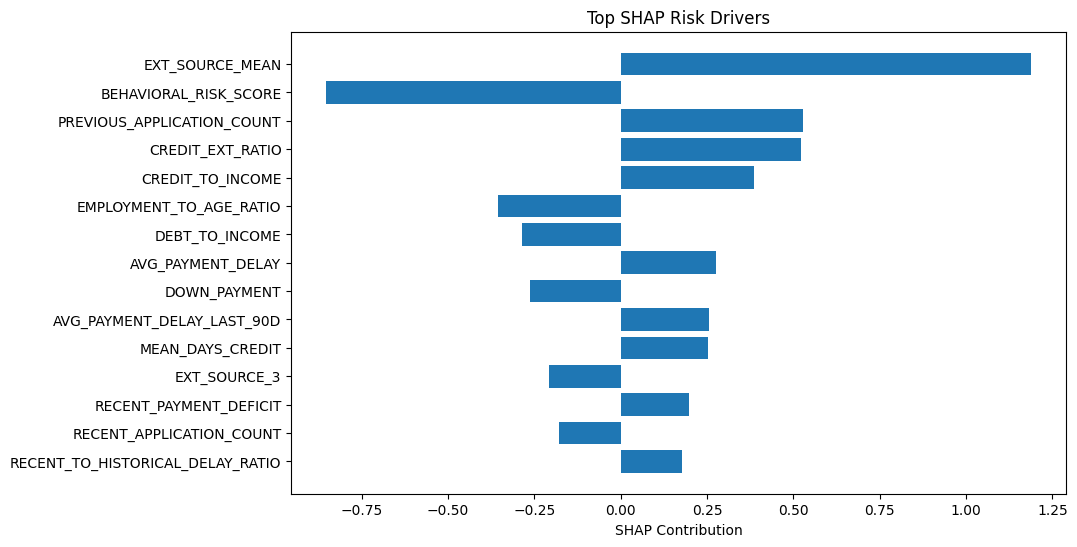

,Feature,SHAP,Feature_Value,ABS_SHAP
10,EXT_SOURCE_MEAN,1.188232,3.352133e-02,1.188232
39,BEHAVIORAL_RISK_SCORE,-0.852122,2.000000e+00,0.852122
19,PREVIOUS_APPLICATION_COUNT,0.528913,1.400000e+01,0.528913
12,CREDIT_EXT_RATIO,0.522928,1.940732e+07,0.522928
1,CREDIT_TO_INCOME,0.385284,1.611111e+01,0.385284
35,EMPLOYMENT_TO_AGE_RATIO,-0.354061,0.000000e+00,0.354061
3,DEBT_TO_INCOME,-0.285361,0.000000e+00,0.285361
24,AVG_PAYMENT_DELAY,0.276463,5.428571e+00,0.276463
6,DOWN_PAYMENT,-0.262454,0.000000e+00,0.262454
28,AVG_PAYMENT_DELAY_LAST_90D,0.257032,1.280000e+01,0.257032



Installment Event Trace:


,SK_ID_PREV,SK_ID_CURR,NUM_INSTALMENT_NUMBER,DAYS_INSTALMENT,DAYS_ENTRY_PAYMENT,AMT_INSTALMENT,AMT_PAYMENT,PAYMENT_DELAY,PAYMENT_DEFICIT
1975577,1431420,116857,16,-58.0,-16.0,26385.300,9643.725,42.0,16741.575
1809,1940227,116857,30,-1267.0,-1232.0,14029.020,74.070,35.0,13954.950
2989046,1940227,116857,15,-1717.0,-1686.0,14618.745,74.070,31.0,14544.675
1102721,1940227,116857,14,-1747.0,-1717.0,14618.745,74.070,30.0,14544.675
107667,1940227,116857,12,-1807.0,-1778.0,14618.745,74.070,29.0,14544.675
141878,1940227,116857,9,-1897.0,-1869.0,14618.745,74.070,28.0,14544.675
2700100,1940227,116857,13,-1777.0,-1749.0,14618.745,74.070,28.0,14544.675
539064,1940227,116857,10,-1867.0,-1840.0,14618.745,74.070,27.0,14544.675
768561,1940227,116857,7,-1957.0,-1931.0,14618.745,74.070,26.0,14544.675
30538,1940227,116857,3,-2077.0,-2051.0,14618.745,74.070,26.0,14544.675


In [18]:

customer_id = 116857

top_positive = investigate_customer_risk(
    customer_id
)


In [19]:
## ext source analysis

# ============================================================
# COUNT CUSTOMERS DOMINATED BY EXT_SOURCE
# ============================================================

ext_features = [

    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_STD",
    "CREDIT_EXT_RATIO"
]

results = []

# ------------------------------------------------------------
# HIGH RISK CUSTOMERS ONLY
# ------------------------------------------------------------

high_risk = application_train[

    application_train["PD"] > 0.70
].copy()

print(
    f"High risk customers: {len(high_risk)}"
)

# ------------------------------------------------------------
# LOOP THROUGH CUSTOMERS
# ------------------------------------------------------------

for idx in high_risk.index:

    customer_shap = pd.DataFrame({

        "Feature": feature_columns,

        "SHAP": shap_values[idx]
    })

    # --------------------------------------------------------
    # POSITIVE SHAP ONLY
    # --------------------------------------------------------

    positive_shap = customer_shap[

        customer_shap["SHAP"] > 0
    ]

    # --------------------------------------------------------
    # TOTAL POSITIVE SHAP
    # --------------------------------------------------------

    total_positive = positive_shap[
        "SHAP"
    ].sum()

    # --------------------------------------------------------
    # EXT_SOURCE SHAP
    # --------------------------------------------------------

    ext_positive = positive_shap[

        positive_shap["Feature"].isin(
            ext_features
        )
    ]["SHAP"].sum()

    # --------------------------------------------------------
    # DOMINANCE RATIO
    # --------------------------------------------------------

    if total_positive > 0:

        ext_ratio = (
            ext_positive
            /
            total_positive
        )

    else:

        ext_ratio = 0

    # --------------------------------------------------------
    # FLAG DOMINATED
    # --------------------------------------------------------

    ext_dominated = (
        ext_ratio >= 0.50
    )

    results.append({

        "SK_ID_CURR": high_risk.loc[idx, "SK_ID_CURR"],

        "PD": high_risk.loc[idx, "PD"],

        "EXT_RATIO": ext_ratio,

        "EXT_DOMINATED": ext_dominated
    })

# ============================================================
# RESULTS
# ============================================================

results_df = pd.DataFrame(results)

results_df.head()

High risk customers: 2242


,SK_ID_CURR,PD,EXT_RATIO,EXT_DOMINATED
0,100020,0.751832,0.552623,True
1,100048,0.716093,0.589025,True
2,100149,0.871242,0.557319,True
3,100189,0.767328,0.529379,True
4,100246,0.718631,0.608544,True


In [20]:
# ============================================================
# SUMMARY
# ============================================================

summary = results_df[
    "EXT_DOMINATED"
].value_counts()

print(summary)

print("\nPercentage dominated:\n")

print(

    results_df[
        "EXT_DOMINATED"
    ].mean()
)

EXT_DOMINATED
True     1589
False     653
Name: count, dtype: int64

Percentage dominated:

0.7087421944692239
